<a href="https://colab.research.google.com/github/Varsh999/dllab/blob/main/loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5228 - val_loss: 0.4136
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3334 - val_loss: 0.2597
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2039 - val_loss: 0.1492
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1058 - val_loss: 0.0634
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0382 - val_loss: 0.0206
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0135 - val_loss: 0.0082
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0055 - val_loss: 0.0034
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 7.7794e-04
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.5474e-04 - val_loss: 5.6107e-04
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.1775e-04 - val_loss: 4.8013e-04
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

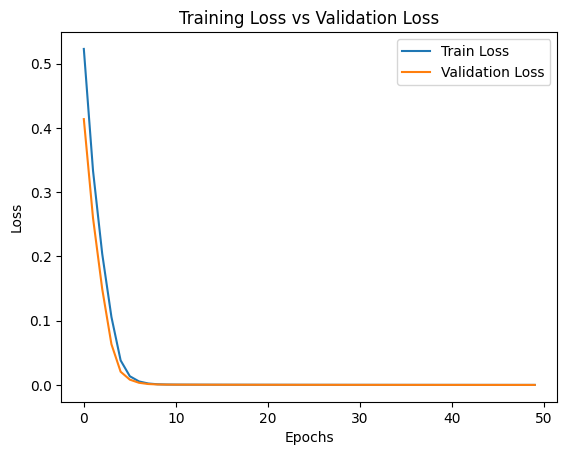

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

def generate_sequence(seq_length=5, num_samples=1000):
  X,y=[],[]
  for _ in range(num_samples):
    seq = np.random.rand(seq_length)
    X.append(seq)
    y.append(seq[-1]+0.1)
  return np.array(X), np.array(y)



seq_length = 5

X,y = generate_sequence(seq_length)

split=int(0.8*len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[:split], y[:split]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    SimpleRNN(10, activation='relu', input_shape=(seq_length,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

test_loss=model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

sample_output = np.array([0.1,0.2,0.3,0.4,0.5]).reshape(1, seq_length,1)
predicted_value = model.predict(sample_output)
print(f"Predicted next value: {predicted_value}")

plt.plot(history.history['loss'], label = 'Train Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training Loss vs Validation Loss")
plt.show()
